In [1]:
import anndata
import numpy as np
import gc
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850-raw-wmeta-ccf.h5ad'
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 3739961 × 550
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_reconstructed', 'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol', 'transcript_identifier'
    uns: 'accessed_on', 'src'

## Plot cell labels

In [3]:
def plot_section(xx, yy, cc = None, val = None, fig_width = 8, fig_height = 8, cmap = None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)
    if cmap is not None:
        plt.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
    elif cc is not None:
        plt.scatter(xx, yy, s=0.5, color=cc, marker='.')
    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

In [4]:
pred = (adata.obs['brain_section_label'] == 'C57BL6J-638850.38')
section = adata.obs[pred]
print("Number of cells in section:",len(section))

Number of cells in section: 120186


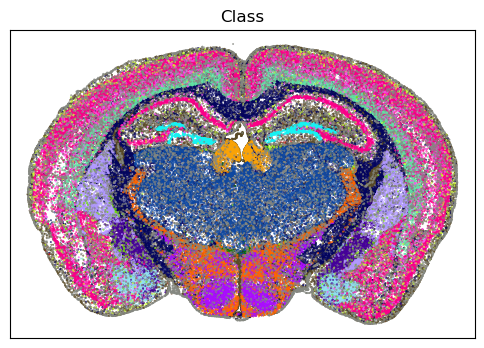

In [5]:
fig, ax = plot_section(section['x_reconstructed'],
                       section['y_reconstructed'],
                       section['class_color'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title("Class")
plt.show()

In [6]:
division_mask = adata.obs['parcellation_division'] == 'Isocortex'
section_mask = adata.obs['brain_section_label'] == 'C57BL6J-638850.38'
pred_iso = division_mask & section_mask
isocortex = adata.obs[pred_iso]

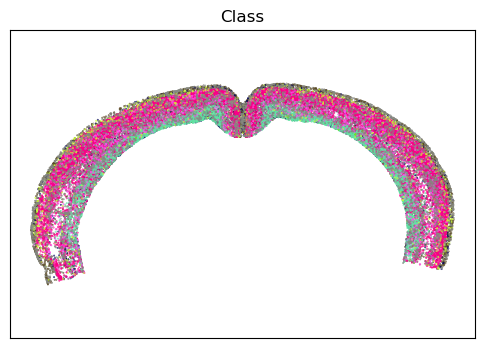

In [7]:
fig, ax = plot_section(isocortex['x_reconstructed'],
                       isocortex['y_reconstructed'],
                       isocortex['class_color'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title("Class")
plt.show()

In [8]:
def plot_section_with_legend(xx, yy, cc=None, val=None, fig_width=8, fig_height=8, cmap=None, legends=None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    if val is not None and cmap is not None:
        sc = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Value")

    elif legends is not None and cc is not None:
        # Ensure pandas Series, drop NaNs
        legends = pd.Series(legends)
        cc = pd.Series(cc)
        valid_mask = legends.notna() & cc.notna()

        xx = xx[valid_mask]
        yy = yy[valid_mask]
        legends = legends[valid_mask]
        cc = cc[valid_mask]

        unique_labels = legends.unique()

        for label in unique_labels:
            mask = legends == label
            color = cc[mask].iloc[0]  # assume consistent color per label
            ax.scatter(xx[mask], yy[mask], s=0.5, marker='.', color=color, label=label)
        ax.legend(markerscale=10, loc = "right", bbox_to_anchor=(1.35, 0.5), fontsize=7)

    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, marker='.', color=cc)

    else:
        ax.scatter(xx, yy, s=0.5, marker='.', color='black')

    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax


In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

def plot_with_inset_zoom(
    xx, yy,
    cc=None,
    val=None,
    fig_width=8, fig_height=8,
    cmap=None,
    legends=None,
    zoom=None,              # pass (xmin, xmax, ymin, ymax)
    zoom_loc='upper right', # where to place inset
    zoom_size=0.4           # fraction of parent axes
):
    """
    Plots your scatter exactly as before, then if `zoom` is given,
    adds an inset axes showing that sub-region magnified.
    """

    # — create main axes —
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.set_aspect('equal', adjustable='box')

    # — scatter logic on main axes —
    if val is not None and cmap is not None:
        sc = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label("Value")

    elif legends is not None and cc is not None:
        legends = pd.Series(legends)
        cc = pd.Series(cc)
        mask = legends.notna() & cc.notna()
        xx_, yy_, legends_, cc_ = xx[mask], yy[mask], legends[mask], cc[mask]
        for label in legends_.unique():
            sel = legends_ == label
            color = cc_[sel].iloc[0]
            ax.scatter(xx_[sel], yy_[sel], s=0.5, marker='.', color=color, label=label)
        ax.legend(markerscale=10, loc="center left",
                  bbox_to_anchor=(1.3, 0.5), fontsize=7)

    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, marker='.', color=cc)
    else:
        ax.scatter(xx, yy, s=0.5, marker='.', color='black')

    # — main axes formatting —
    ax.set_xlim(0, 11)
    ax.set_ylim(11, 0)
    ax.set_xticks([])
    ax.set_yticks([])

    # — inset zoom, if requested —
    if zoom is not None:
        xmin, xmax, ymin, ymax = zoom
        # create inset
        axins = inset_axes(
            ax,
            width=f"{zoom_size*100}%",  # e.g. "40%"
            height=f"{zoom_size*100}%",
            loc=zoom_loc
        )
        axins.set_aspect('equal', adjustable='box')

        # scatter same data into inset
        if val is not None and cmap is not None:
            axins.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        elif legends is not None and cc is not None:
            for label in legends.unique():
                sel = legends == label
                color = cc[sel].iloc[0]
                axins.scatter(xx[sel], yy[sel], s=0.5, marker='.', color=color)
        elif cc is not None:
            axins.scatter(xx, yy, s=0.5, marker='.', color=cc)
        else:
            axins.scatter(xx, yy, s=0.5, marker='.', color='black')

        # zoom to the specified box
        axins.set_xlim(xmin, xmax)
        axins.set_ylim(ymax, ymin)  # invert y so smaller is “up”
        axins.set_xticks([])
        axins.set_yticks([])

        # draw connecting lines
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    return fig, ax


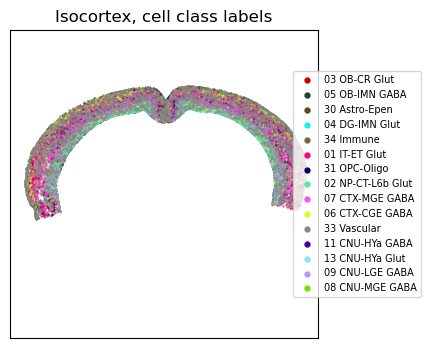

In [33]:
fig, ax = plot_section_with_zoom(isocortex['x_reconstructed'],
                                   isocortex['y_reconstructed'],
                                   cc = isocortex['class_color'],
                                   legends=isocortex['class'],
                                   fig_height=4,
                                   fig_width=6,
                                #    zoom=(5,6,0,5),
                                   )
res = ax.set_title("Isocortex, cell class labels")
plt.show()

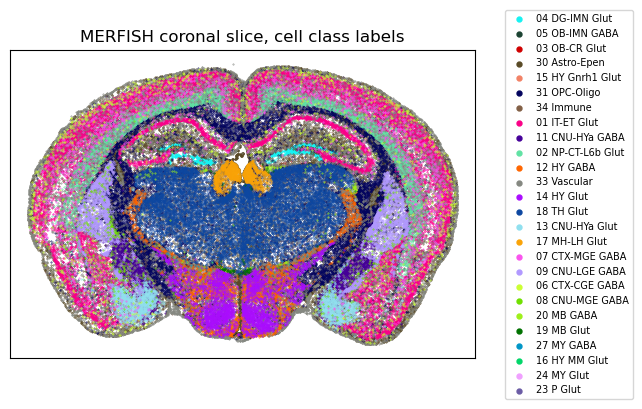

In [9]:
fig, ax = plot_section_with_legend(section['x_reconstructed'],
                                   section['y_reconstructed'],
                                   cc = section['class_color'],
                                   legends=section['class'],
                                   fig_height=4,
                                   fig_width=6)
res = ax.set_title("MERFISH coronal slice, cell class labels")
plt.show()

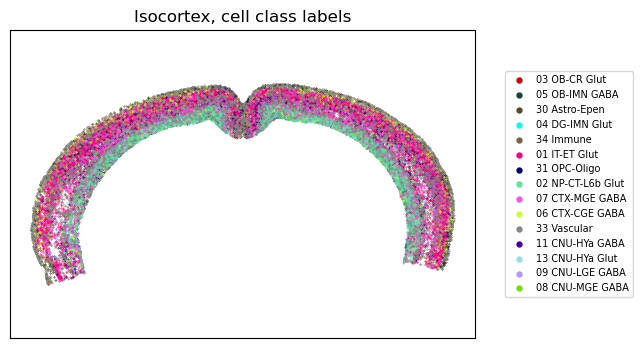

In [10]:
fig, ax = plot_section_with_legend(isocortex['x_reconstructed'],
                                   isocortex['y_reconstructed'],
                                   cc = isocortex['class_color'],
                                   legends=isocortex['class'],
                                   fig_height=4,
                                   fig_width=6)
res = ax.set_title("Isocortex, cell class labels")
plt.show()

In [ ]:
def plot_section_with_legend_zoom(xx, yy, cc=None, val=None, fig_width=8, fig_height=8, cmap=None, legends=None, xlim=None, ylim=None):
    """
    Plot a section with legend and zoom into a specified region.

    Parameters:
        xx, yy: Coordinates (pandas Series or array-like)
        cc: Color values (optional)
        val: Values for colormap (optional)
        fig_width, fig_height: Figure size
        cmap: Colormap (optional)
        legends: Labels for legend (optional)
        xlim: Tuple (xmin, xmax) for x-axis limits (optional)
        ylim: Tuple (ymin, ymax) for y-axis limits (optional)
    """
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    if val is not None and cmap is not None:
        sc = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Value")
    elif legends is not None and cc is not None:
        legends = pd.Series(legends)
        cc = pd.Series(cc)
        valid_mask = legends.notna() & cc.notna()
        xx = xx[valid_mask]
        yy = yy[valid_mask]
        legends = legends[valid_mask]
        cc = cc[valid_mask]
        unique_labels = legends.unique()
        for label in unique_labels:
            mask = legends == label
            color = cc[mask].iloc[0]
            ax.scatter(xx[mask], yy[mask], s=0.5, marker='.', color=color, label=label)
        ax.legend(markerscale=10, loc="right", bbox_to_anchor=(1.35, 0.5), fontsize=7)
    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, marker='.', color=cc)
    else:
        ax.scatter(xx, yy, s=0.5, marker='.', color='black')

    # Zoom to the right top quarter: x in (5.5, 11), y in (0, 5.5)
    # Set axis limits to zoom into the right top quarter of the image
    # The original full image is x in (0, 11), y in (0, 11)
    # Right top quarter: x in (5.5, 11), y in (0, 5.5)
    if xlim is not None:
        ax.set_xlim(*xlim)
    else:
        ax.set_xlim(5.5, 11)
    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        ax.set_ylim(5.5, 0)  # y decreases downward in image coordinates

    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax


In [23]:
def plot_section_with_legend_zoom(xx, yy, cc=None, val=None, fig_width=8, fig_height=8, cmap=None, legends=None, xlim=None, ylim=None):
    """
    Plot a section with legend and zoom into a specified region.

    Parameters:
        xx, yy: Coordinates (pandas Series or array-like)
        cc: Color values (optional)
        val: Values for colormap (optional)
        fig_width, fig_height: Figure size
        cmap: Colormap (optional)
        legends: Labels for legend (optional)
        xlim: Tuple (xmin, xmax) for x-axis limits (optional)
        ylim: Tuple (ymin, ymax) for y-axis limits (optional)
    """
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    if val is not None and cmap is not None:
        sc = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Value")
    elif legends is not None and cc is not None:
        legends = pd.Series(legends)
        cc = pd.Series(cc)
        valid_mask = legends.notna() & cc.notna()
        xx = xx[valid_mask]
        yy = yy[valid_mask]
        legends = legends[valid_mask]
        cc = cc[valid_mask]
        unique_labels = legends.unique()
        for label in unique_labels:
            mask = legends == label
            color = cc[mask].iloc[0]
            ax.scatter(xx[mask], yy[mask], s=0.5, marker='.', color=color, label=label)
        ax.legend(markerscale=10, loc="right", bbox_to_anchor=(1.35, 0.5), fontsize=7)
    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, marker='.', color=cc)
    else:
        ax.scatter(xx, yy, s=0.5, marker='.', color='black')

    # Zoom to the right top quarter: x in (5.5, 11), y in (0, 5.5)
    # Set axis limits to zoom into the right top quarter of the image
    # The original full image is x in (0, 11), y in (0, 11)
    # Right top quarter: x in (5.5, 11), y in (0, 5.5)
    if xlim is not None:
        ax.set_xlim(*xlim)
    else:
        ax.set_xlim(5.5, 11)
    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        ax.set_ylim(5.5, 0)  # y decreases downward in image coordinates

    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax


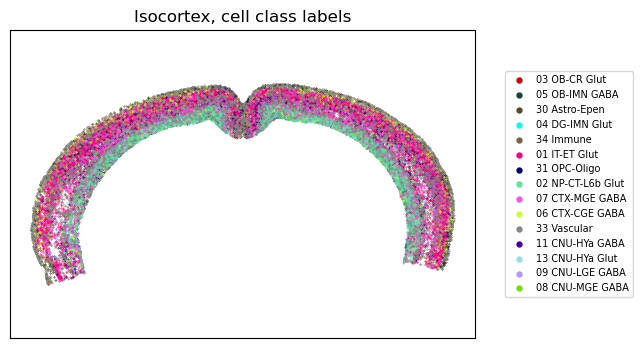

In [24]:
fig, ax = plot_section_with_legend_zoom(isocortex['x_reconstructed'],
                                   isocortex['y_reconstructed'],
                                   cc = isocortex['class_color'],
                                   legends=isocortex['class'],
                                   fig_height=4,
                                   fig_width=6,
                                #    xlim=(2, 3),
                                #    ylim=(8, 7),
                                   )
res = ax.set_title("Isocortex, cell class labels")
plt.show()

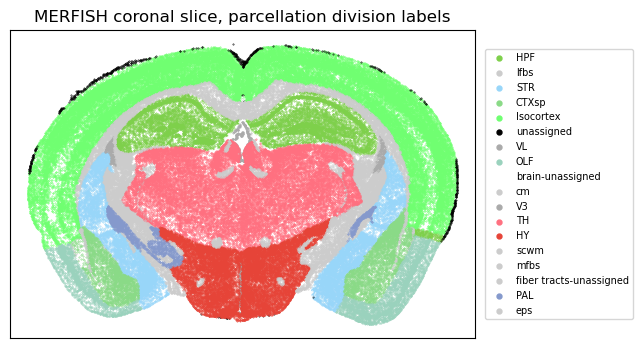

In [12]:
fig, ax = plot_section_with_legend(section['x_reconstructed'],
                                   section['y_reconstructed'],
                                   cc = section['parcellation_division_color'],
                                   legends=section['parcellation_division'],
                                   fig_height=4,
                                   fig_width=6)
res = ax.set_title("MERFISH coronal slice, parcellation division labels")
plt.show()

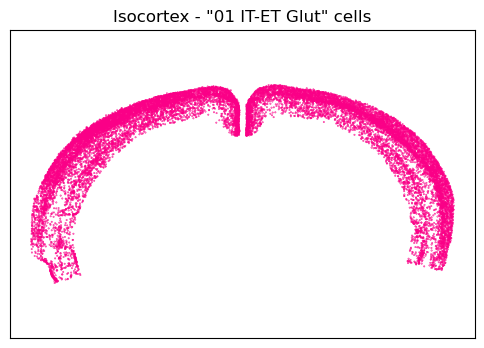

In [13]:
select_class = "01 IT-ET Glut"
iso_class = isocortex[isocortex['class'] == select_class]
fig, ax = plot_section(iso_class['x_reconstructed'],
                       iso_class['y_reconstructed'],
                       iso_class['class_color'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title(f"Isocortex - \"{select_class}\" cells")
plt.show()

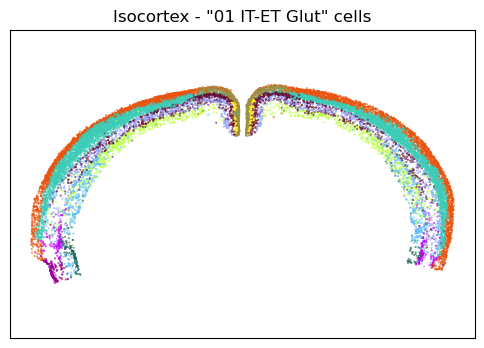

In [14]:
select_class = "01 IT-ET Glut"
iso_class = isocortex[isocortex['class'] == select_class]
fig, ax = plot_section(iso_class['x_reconstructed'],
                       iso_class['y_reconstructed'],
                       iso_class['subclass_color'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title(f"Isocortex - \"{select_class}\" cells")
plt.show()

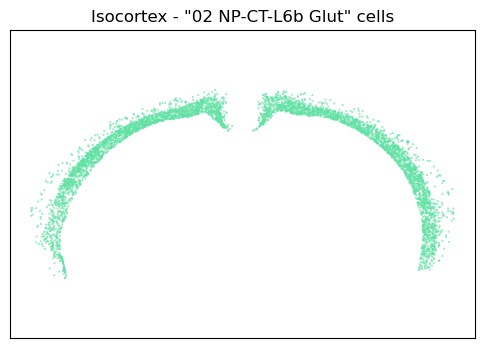

In [15]:
select_class = "02 NP-CT-L6b Glut"
iso_class = isocortex[isocortex['class'] == select_class]
fig, ax = plot_section(iso_class['x_reconstructed'],
                       iso_class['y_reconstructed'],
                       iso_class['class_color'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title(f"Isocortex - \"{select_class}\" cells")
plt.show()

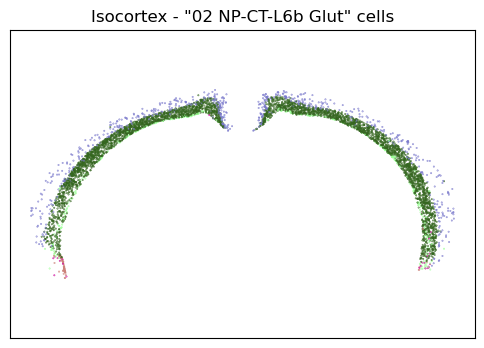

In [16]:
select_class = "02 NP-CT-L6b Glut"
iso_class = isocortex[isocortex['class'] == select_class]
fig, ax = plot_section(iso_class['x_reconstructed'],
                       iso_class['y_reconstructed'],
                       iso_class['subclass_color'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title(f"Isocortex - \"{select_class}\" cells")
plt.show()